In [1]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass
import pickle
import time
from typing import Optional

In [69]:
def plot_st(st_matrix, f, title="Stockwell Transform"):
    plt.figure(figsize=(12, 8))

    extent = [0, st_matrix.shape[1], 0, f]

    plt.imshow(
        np.abs(st_matrix),
        extent=extent,
        aspect='auto',
        origin='lower',
        cmap='viridis'
    )

    plt.colorbar(label="Magnitude")
    plt.xlabel("Time")
    plt.ylabel("Frequency")

    plt.yscale("log")
    plt.ylim(max(0.05, 0), f)

    plt.title(title)
    plt.tight_layout()
    plt.show()


def stockwell(
    x: np.ndarray,
    dt: float,
    kmin: int = 0,
    kmax: Optional[int] = None,
    kstep: int = 1,
    k_bins: Optional[np.ndarray] = None,
    chunk_size: int = 256,
    mmap_path: Optional[str] = None,
    decimate: int = 1,
):
    real = np.float16
    out_dtype = np.complex64

    x = np.asarray(x, dtype=real)
    n = x.size

    if kmax is None:
        kmax = n // 2

    if k_bins is None:
        k_bins = np.arange(kmin, kmax + 1, kstep, dtype=int)

    num_k  = k_bins.size

    n_out = len(range(0, n, decimate))

    if mmap_path is None:
        S = np.zeros((num_k, n_out), dtype=out_dtype)
    else:
        S = np.memmap(mmap_path, mode="w+", dtype=out_dtype, shape=(num_k, n_out))

    row_cursor = (kmin==0)
    if kmin == 0:
        S[0, :] = np.mean(x).astype(real)
        k_bins = k_bins[1:]
        num_k-=1

    X = np.fft.fft(x)
    X2 = np.concatenate([X, X])

    t_front = np.arange(n, dtype=np.float32)**2
    t_back  = np.arange(-n, 0, dtype=np.float32)**2

    cols = np.arange(n)

    for i in range(0, num_k, chunk_size):

        k_batch = k_bins[i : i + chunk_size]
        B = k_batch.size
        if B == 0:
            break

        scale = -2.0 * (np.pi ** 2)
        scale = np.float16(scale) / (k_batch.astype(np.float32) ** 2)

        s = scale[:, None]

        gauss = np.exp(s * t_front[None, :], dtype=np.float32) + np.exp(s * t_back[None, :], dtype=np.float32)

        idx_start = k_batch[:, None] + cols[None, :]
        slices = X2[idx_start]

        rows = np.fft.ifft(slices * gauss, axis=1)
        S[row_cursor:row_cursor + B, :] = rows[:, ::decimate].astype(out_dtype, copy=False)
        row_cursor += B

    f_hz = kmax / (n * dt)

    return S, f_hz

def fdost2m(arr: np.ndarray, f: int = None):
    #positive values only
    n = len(arr)
    m = np.zeros((n, n*2), dtype=complex)

    m[0] = arr[0]
    m[1] = arr[1]

    index = 2
    n*=2
    for i in range(1,int(np.log2(n//2))):
        k = 2**i
        j = n//k
        for p in range(k):
            m[index:index+k, j*p:j*(p+1)] = arr[index+p]
        index+=k
        if k != None:
            if index >= f:
                break
    
    if k != None:
        m = m[:f]

    return m


def fDOST(h: np.ndarray):
    n = len(h)
    H = np.fft.fft(h, norm='ortho')
    S = np.zeros(n, dtype=complex)

    S[n//2] = H[0]
    S[n//2 + 1] = -H[1] # simplifies to -1: np.exp(-2j*(n//2) * np.pi/n)

    for p in range(2, int(np.log2(n))):
        b = 2**(p-1)
        v = b + 2**(p-2)
        k = np.arange(v - b//2, v + b//2)
        tau = np.arange(b)

        R = np.exp(-1j*np.pi*tau)
        V = np.fft.ifft(H[k], norm='ortho')

        T = R*V
        S[n//2+b: n//2+b+b] = T


    S[1:n//2] = np.conj(S[n//2+1:][::-1])

    S[0] = H[n//2]

    return S

In [3]:
@dataclass
class StationTF:

    HVSRN: np.ndarray | None
    HVSRE: np.ndarray | None

    fullHVSRN: np.ndarray | None
    fullHVSRE: np.ndarray | None

In [4]:
with open("sel.pkl", "rb") as f:
    sel_N, sel_E, sel_Z = pickle.load(f)

waveforms_N_data = [xt.data for xt in sel_N]
waveforms_E_data = [xt.data for xt in sel_E]
waveforms_Z_data = [xt.data for xt in sel_Z]

waveforms_N_delta = [st.stats.delta for st in sel_N]
waveforms_E_delta = [st.stats.delta for st in sel_E]
waveforms_Z_delta = [st.stats.delta for st in sel_Z]

In [20]:
p2 = 1 << (waveforms_E_data[0].size.bit_length() - 1)
x = waveforms_E_data[0][:p2]
dt = waveforms_E_delta[0]

"""
from scipy.signal import decimate
x = decimate(x, 2, ftype="fir", zero_phase=True)
dt = dt * 2
"""

'\nfrom scipy.signal import decimate\nx = decimate(x, 2, ftype="fir", zero_phase=True)\ndt = dt * 2\n'

In [21]:
print(x.size)

16384


In [70]:
n = x.size
dt = 0.01

kmin = int(0.1 * n * dt)
kmax = int(20.0 * n * dt)

k_bins = np.unique(np.round(np.logspace(np.log10(kmin), np.log10(kmax), num=300)).astype(int))

S, f_hz = stockwell(x, dt=dt, k_bins=k_bins, kmax=kmax, decimate=20)

In [66]:
st_matrix_E, k = stockwell(x,dt, kmin=0, kmax=(x.size)//2, kstep=4, chunk_size=500, decimate=50)
ste = fDOST(x)
m = fdost2m(ste[p2//2+2:], int(k))

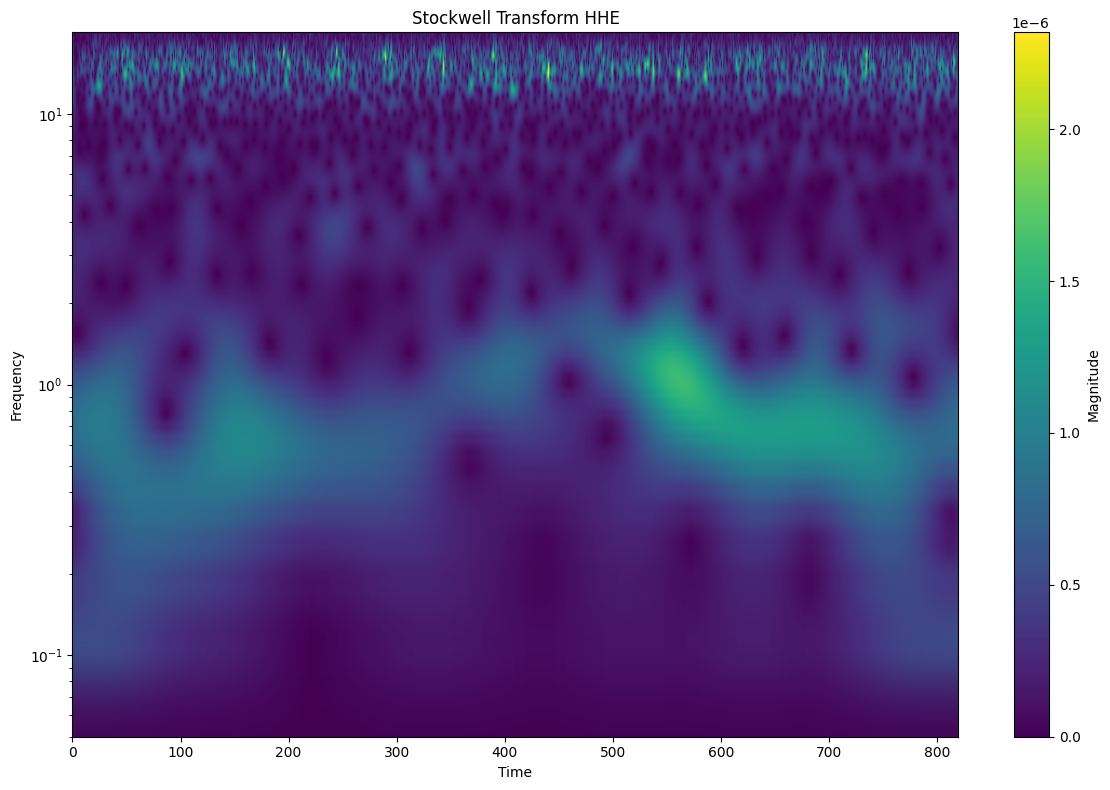

In [71]:
plot_st(S, f_hz, title="Stockwell Transform HHE")

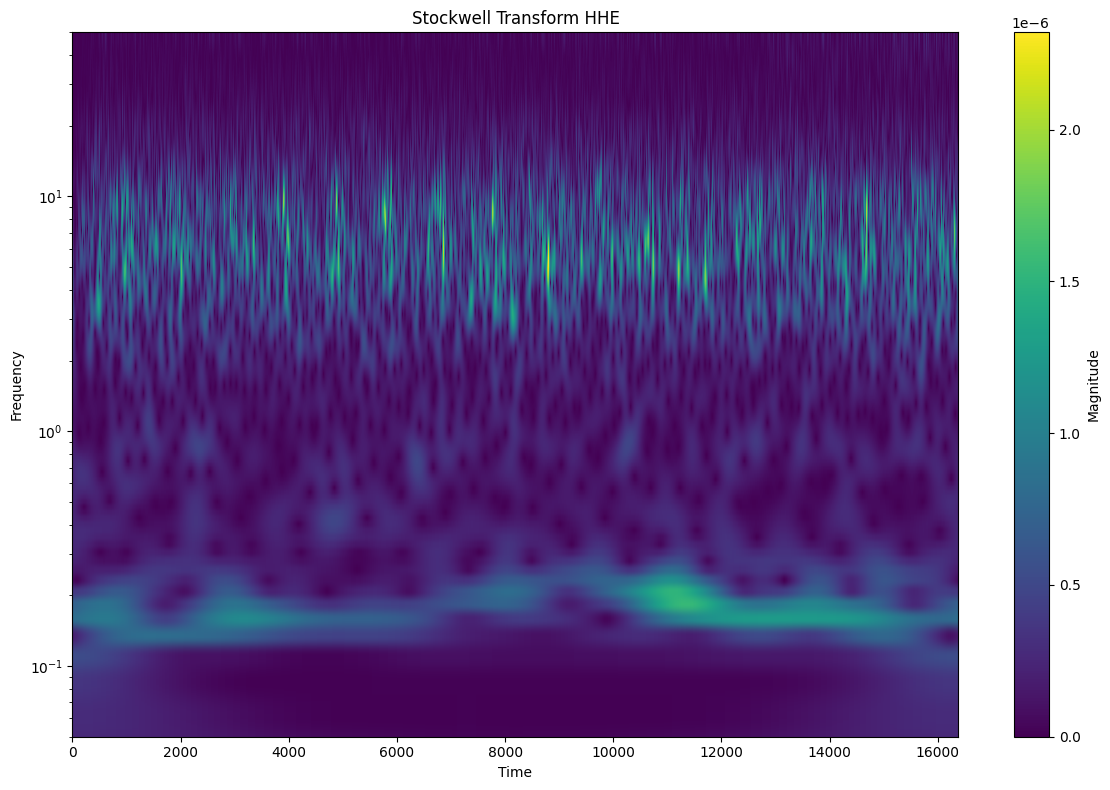

In [52]:
plot_st(st_matrix_E, k, title="Stockwell Transform HHE")

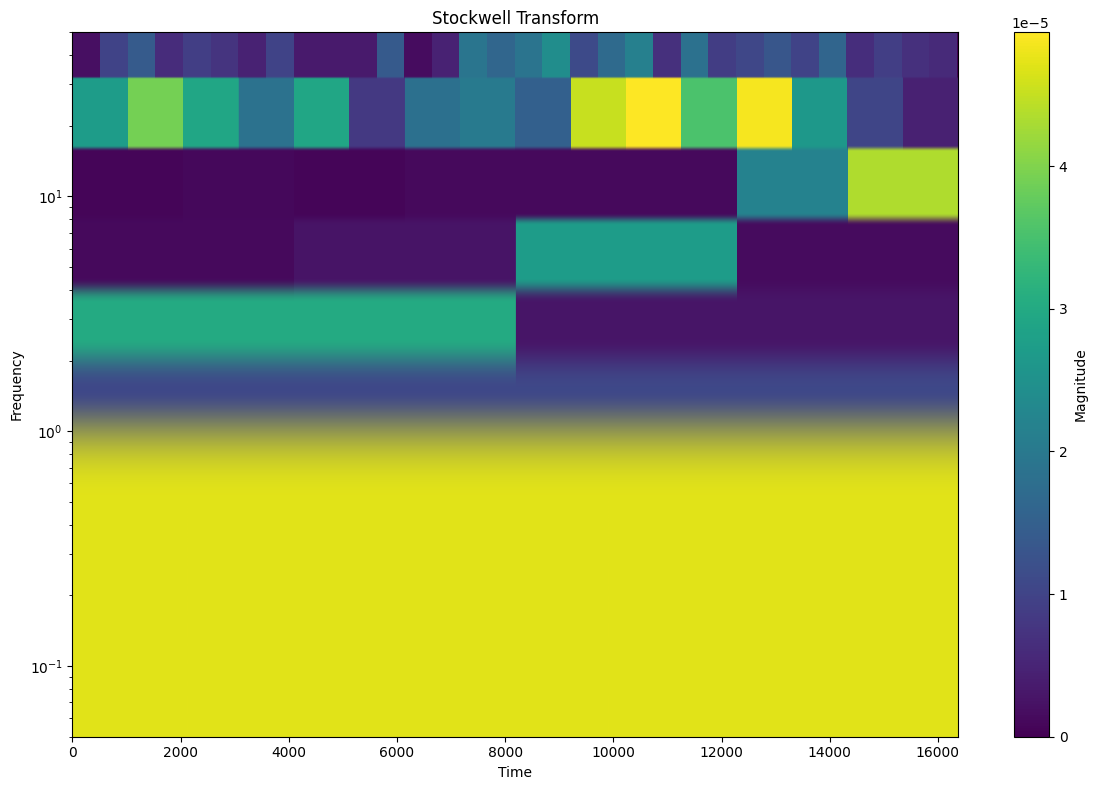

In [51]:
plot_st(m, k)